# Day 2 — Technical Indicators + Signal Generation

**Goal**: Compute MACD, RSI, EMA, Bollinger Bands, ATR for all 10 stocks and generate BUY/SELL/HOLD signals.

| Indicator | Parameters | Role |
|-----------|-----------|------|
| EMA | 20, 50 | Trend direction |
| MACD | 12, 26, 9 | Momentum crossover |
| RSI | 14 | Overbought/Oversold |
| Bollinger Bands | 20, 2σ | Mean reversion context |
| ATR | 14 | Volatility / stop-loss sizing |

**Signal rules**:
- 🟢 **BUY**: RSI < 40 AND MACD > Signal line AND Close > EMA(50)
- 🔴 **SELL**: RSI > 65 OR Close < 6% trailing stop (60-day window)
- ⚪ **HOLD**: everything else

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

COLORS = {
    'price': '#58a6ff', 'ema20': '#f78166', 'ema50': '#3fb950',
    'macd': '#58a6ff',  'signal_line': '#f78166',
    'hist_pos': '#3fb950', 'hist_neg': '#f85149',
    'rsi': '#d2a8ff', 'buy': '#3fb950', 'sell': '#f85149',
}

print('Environment ready ✓')

Environment ready ✓


## 1. Load Data + Generate Signals

In [2]:
from src.data.loader import DataLoader
from src.signals.generator import SignalGenerator

loader = DataLoader()
ohlcv  = loader.load(force_download=False)

sg      = SignalGenerator(ohlcv)
signals = sg.generate_all()

print(f'\nSignals generated for: {list(signals.keys())}')

23:20:01 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31


23:20:01 | INFO | DataLoader |   AAPL   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


23:20:01 | INFO | DataLoader |   MSFT   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


23:20:01 | INFO | DataLoader |   GOOGL  — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


23:20:01 | INFO | DataLoader |   AMZN   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


...

23:20:01 | INFO | SignalGenerator |   JNJ    — 1711 rows | BUY: 17 | SELL: 633 | HOLD: 1061


23:20:01 | INFO | SignalGenerator |   TSLA   — 1711 rows | BUY: 13 | SELL: 1364 | HOLD: 334


23:20:01 | INFO | SignalGenerator |   NVDA   — 1711 rows | BUY: 15 | SELL: 955 | HOLD: 741


23:20:01 | INFO | SignalGenerator | Done. 10 tickers processed.



Signals generated for: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'BAC', 'XOM', 'JNJ', 'TSLA', 'NVDA']


## 2. Signal Summary Table

In [3]:
summary = sg.summary()
print('=== Signal Summary (2018–2024) ===')
display(summary)

=== Signal Summary (2018–2024) ===


,BUY signals,SELL signals,HOLD signals,Total rows,BUY rate %,SELL rate %,Avg RSI,Avg ATR
Ticker,,,,,,,,
AAPL,14,800,897,1711,0.8,46.8,55.6,2.86
MSFT,15,579,1117,1711,0.9,33.8,55.3,5.19
GOOGL,12,704,995,1711,0.7,41.1,53.9,2.47
AMZN,19,835,857,1711,1.1,48.8,53.2,3.54
JPM,15,711,985,1711,0.9,41.6,53.9,2.65
BAC,18,868,825,1711,1.1,50.7,52.2,0.74
XOM,18,886,807,1711,1.1,51.8,51.5,1.61
JNJ,17,633,1061,1711,1.0,37.0,51.5,2.16
TSLA,13,1364,334,1711,0.8,79.7,52.9,8.06


## 3. AAPL — Price + EMA + Signals

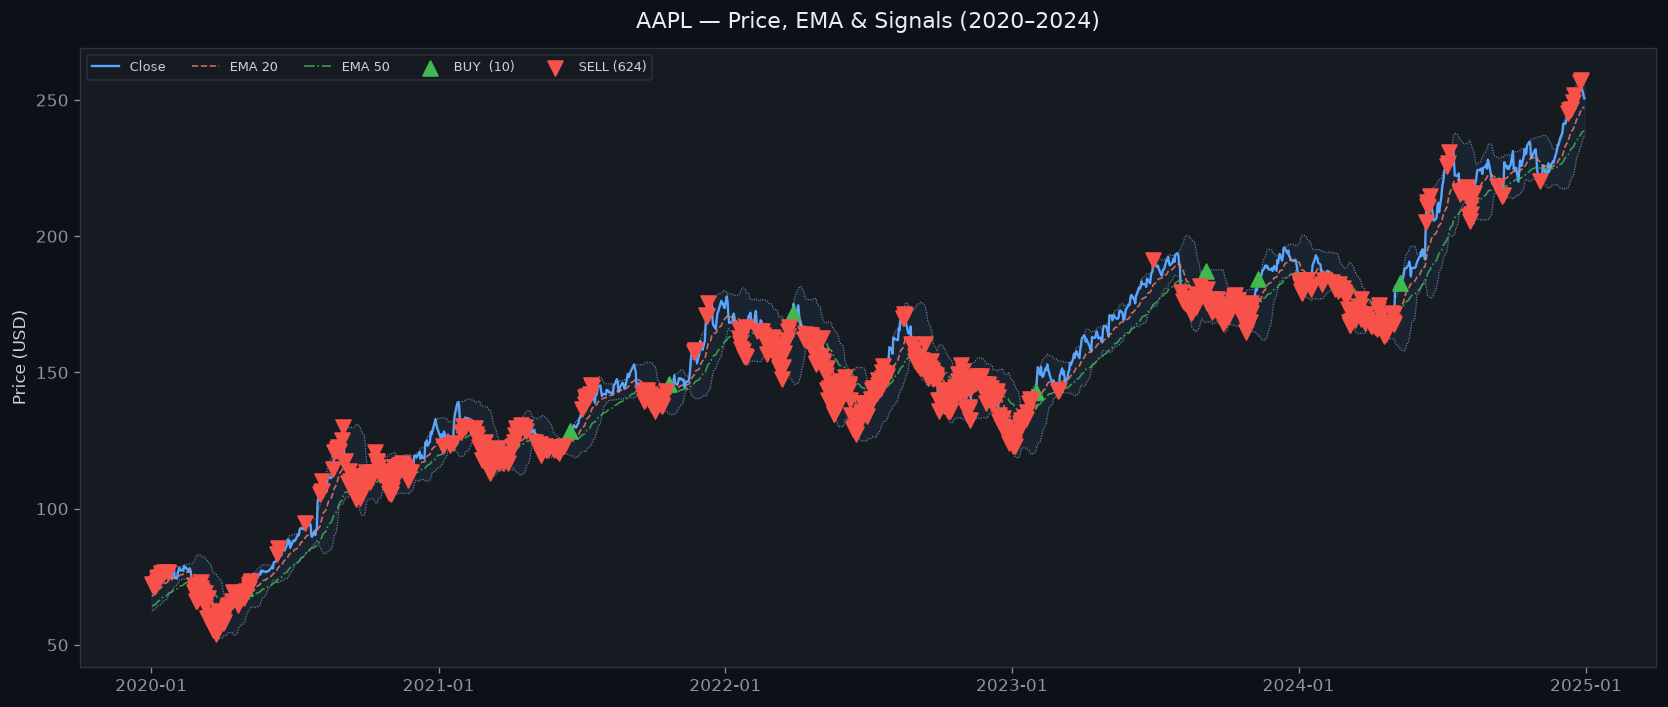

Saved → reports/day2_aapl_signals.png


In [4]:
def plot_price_signals(ticker, df, year_from=2020, year_to=2024):
    mask = (df.index.year >= year_from) & (df.index.year <= year_to)
    d = df[mask]
    buys  = d[d['Signal'] ==  1]
    sells = d[d['Signal'] == -1]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(d.index, d['Close'],  color=COLORS['price'], lw=1.4, label='Close', zorder=2)
    ax.plot(d.index, d['EMA_20'], color=COLORS['ema20'], lw=1.0, label='EMA 20', alpha=0.8, ls='--')
    ax.plot(d.index, d['EMA_50'], color=COLORS['ema50'], lw=1.0, label='EMA 50', alpha=0.8, ls='-.')
    ax.plot(d.index, d['BB_upper'], color='#8b949e', lw=0.6, ls=':')
    ax.plot(d.index, d['BB_lower'], color='#8b949e', lw=0.6, ls=':')
    ax.fill_between(d.index, d['BB_upper'], d['BB_lower'], alpha=0.07, color='#58a6ff')

    if len(buys)  > 0:
        ax.scatter(buys.index,  buys['Close'],  marker='^', color=COLORS['buy'],  s=80, zorder=5, label=f'BUY  ({len(buys)})')
    if len(sells) > 0:
        ax.scatter(sells.index, sells['Close'], marker='v', color=COLORS['sell'], s=80, zorder=5, label=f'SELL ({len(sells)})')

    ax.set_title(f'{ticker} — Price, EMA & Signals ({year_from}–{year_to})', fontsize=13, color='#e6edf3', pad=12)
    ax.set_ylabel('Price (USD)')
    ax.legend(ncol=6, fontsize=8, loc='upper left', facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    return fig

fig = plot_price_signals('AAPL', signals['AAPL'])
fig.savefig('../reports/day2_aapl_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day2_aapl_signals.png')

## 4. MACD Panel

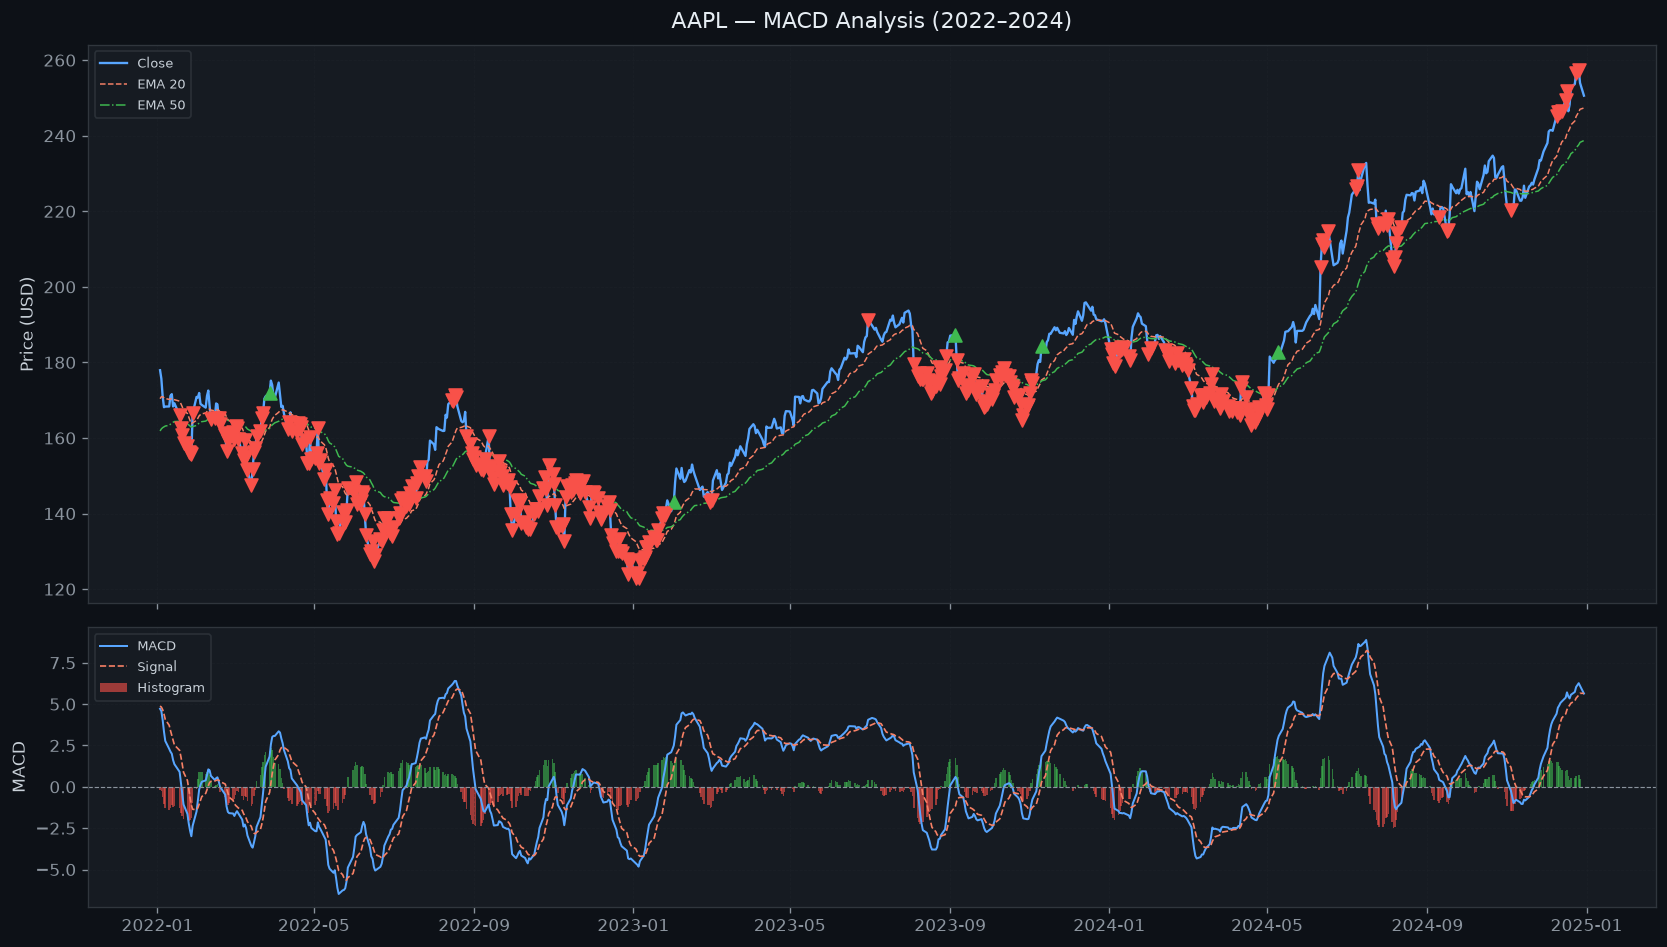

Saved → reports/day2_aapl_macd.png


In [5]:
def plot_macd(ticker, df, year_from=2022, year_to=2024):
    mask = (df.index.year >= year_from) & (df.index.year <= year_to)
    d = df[mask]
    buys  = d[d['Signal'] ==  1]
    sells = d[d['Signal'] == -1]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1.5]})
    fig.subplots_adjust(hspace=0.05)

    ax1.plot(d.index, d['Close'],  color=COLORS['price'], lw=1.4, label='Close')
    ax1.plot(d.index, d['EMA_20'], color=COLORS['ema20'], lw=0.9, ls='--', label='EMA 20')
    ax1.plot(d.index, d['EMA_50'], color=COLORS['ema50'], lw=0.9, ls='-.', label='EMA 50')
    if len(buys)  > 0: ax1.scatter(buys.index,  buys['Close'],  marker='^', color=COLORS['buy'],  s=60, zorder=5)
    if len(sells) > 0: ax1.scatter(sells.index, sells['Close'], marker='v', color=COLORS['sell'], s=60, zorder=5)
    ax1.set_title(f'{ticker} — MACD Analysis ({year_from}–{year_to})', fontsize=13, color='#e6edf3', pad=10)
    ax1.set_ylabel('Price (USD)')
    ax1.legend(fontsize=8, loc='upper left', facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
    ax1.grid(True, alpha=0.4)

    ax2.plot(d.index, d['MACD'],        color=COLORS['macd'],        lw=1.2, label='MACD')
    ax2.plot(d.index, d['MACD_signal'], color=COLORS['signal_line'], lw=1.0, ls='--', label='Signal')
    colors_hist = [COLORS['hist_pos'] if v >= 0 else COLORS['hist_neg'] for v in d['MACD_diff']]
    ax2.bar(d.index, d['MACD_diff'], color=colors_hist, alpha=0.6, width=1.2, label='Histogram')
    ax2.axhline(0, color='#8b949e', lw=0.7, ls='--')
    ax2.set_ylabel('MACD')
    ax2.legend(fontsize=8, loc='upper left', facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
    ax2.grid(True, alpha=0.4)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    return fig

fig = plot_macd('AAPL', signals['AAPL'])
fig.savefig('../reports/day2_aapl_macd.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day2_aapl_macd.png')

## 5. RSI Panel

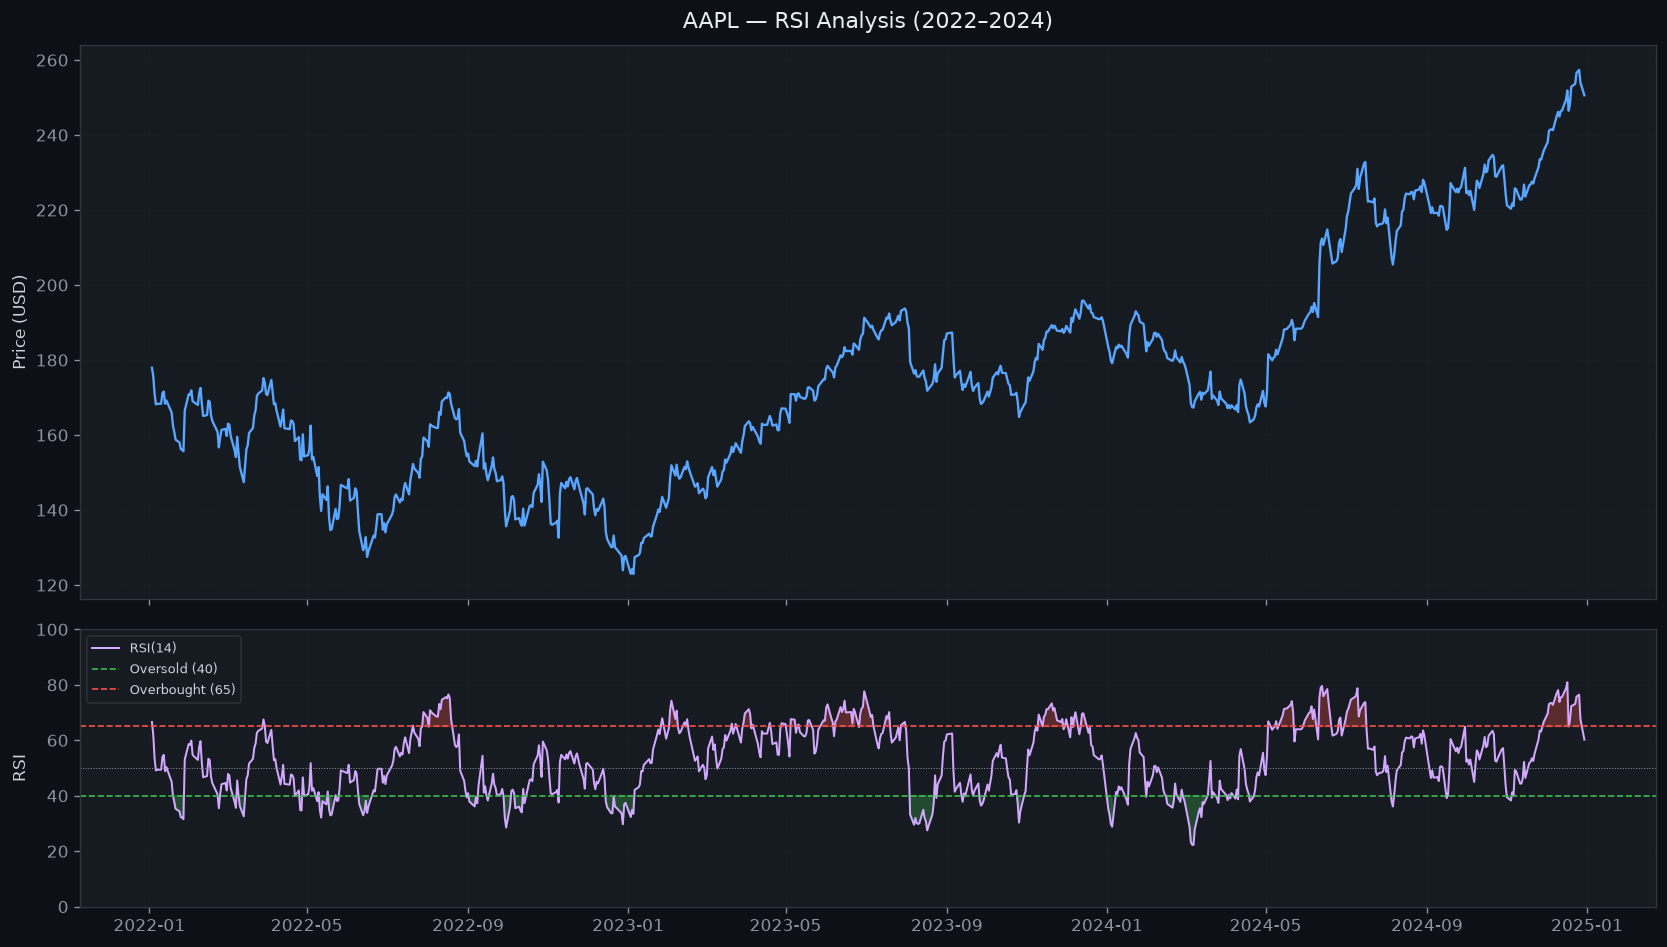

Saved → reports/day2_aapl_rsi.png


In [6]:
def plot_rsi(ticker, df, year_from=2022, year_to=2024):
    mask = (df.index.year >= year_from) & (df.index.year <= year_to)
    d = df[mask]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1.5]})
    fig.subplots_adjust(hspace=0.05)

    ax1.plot(d.index, d['Close'], color=COLORS['price'], lw=1.4)
    ax1.set_title(f'{ticker} — RSI Analysis ({year_from}–{year_to})', fontsize=13, color='#e6edf3', pad=10)
    ax1.set_ylabel('Price (USD)')
    ax1.grid(True, alpha=0.4)

    ax2.plot(d.index, d['RSI'], color=COLORS['rsi'], lw=1.2, label='RSI(14)')
    ax2.axhline(40, color=COLORS['buy'],  lw=1.0, ls='--', label='Oversold (40)')
    ax2.axhline(65, color=COLORS['sell'], lw=1.0, ls='--', label='Overbought (65)')
    ax2.axhline(50, color='#8b949e',      lw=0.6, ls=':')
    ax2.fill_between(d.index, d['RSI'], 40, where=(d['RSI'] < 40), alpha=0.3, color=COLORS['buy'])
    ax2.fill_between(d.index, d['RSI'], 65, where=(d['RSI'] > 65), alpha=0.3, color=COLORS['sell'])
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.legend(fontsize=8, loc='upper left', facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
    ax2.grid(True, alpha=0.4)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    return fig

fig = plot_rsi('AAPL', signals['AAPL'])
fig.savefig('../reports/day2_aapl_rsi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day2_aapl_rsi.png')

## 6. BUY Signal Heatmap — All Tickers × All Years

Total BUY signals across all tickers: 156


,2018,2019,2020,2021,2022,2023,2024
AAPL,2,2,1,3,2,3,1
MSFT,2,1,2,0,3,3,4
GOOGL,1,2,2,0,2,3,2
AMZN,0,4,3,5,2,3,2
JPM,2,3,3,1,4,2,0
BAC,1,3,3,2,4,3,2
XOM,2,4,2,1,3,2,4
JNJ,1,4,5,2,3,2,0
TSLA,3,2,1,2,1,3,1
NVDA,1,3,1,3,2,3,2


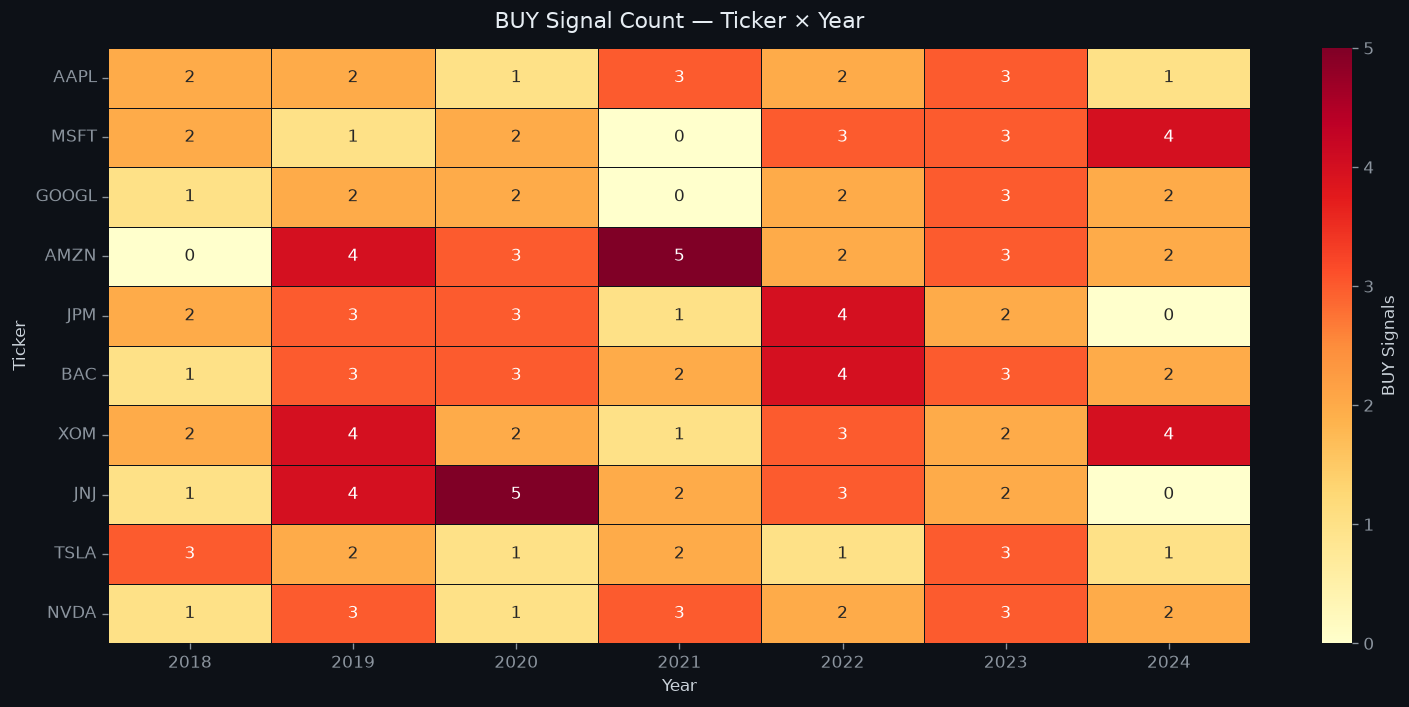

Saved → reports/day2_signal_heatmap.png


In [7]:
ALL_YEARS = list(range(2018, 2025))
buy_counts = {}
for ticker, df in signals.items():
    buy_df = df[df['Signal'] == 1]
    if len(buy_df) > 0:
        counts = buy_df.groupby(buy_df.index.year).size()
    else:
        counts = pd.Series(dtype=int)
    buy_counts[ticker] = counts.reindex(ALL_YEARS, fill_value=0)

heatmap_df = pd.DataFrame(buy_counts).T
heatmap_df.columns = [str(c) for c in heatmap_df.columns]

print(f'Total BUY signals across all tickers: {heatmap_df.values.sum()}')
display(heatmap_df)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'label': 'BUY Signals'})
ax.set_title('BUY Signal Count — Ticker × Year', fontsize=13, color='#e6edf3', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Ticker')
plt.tight_layout()
fig.savefig('../reports/day2_signal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day2_signal_heatmap.png')

## 7. ATR Volatility Comparison

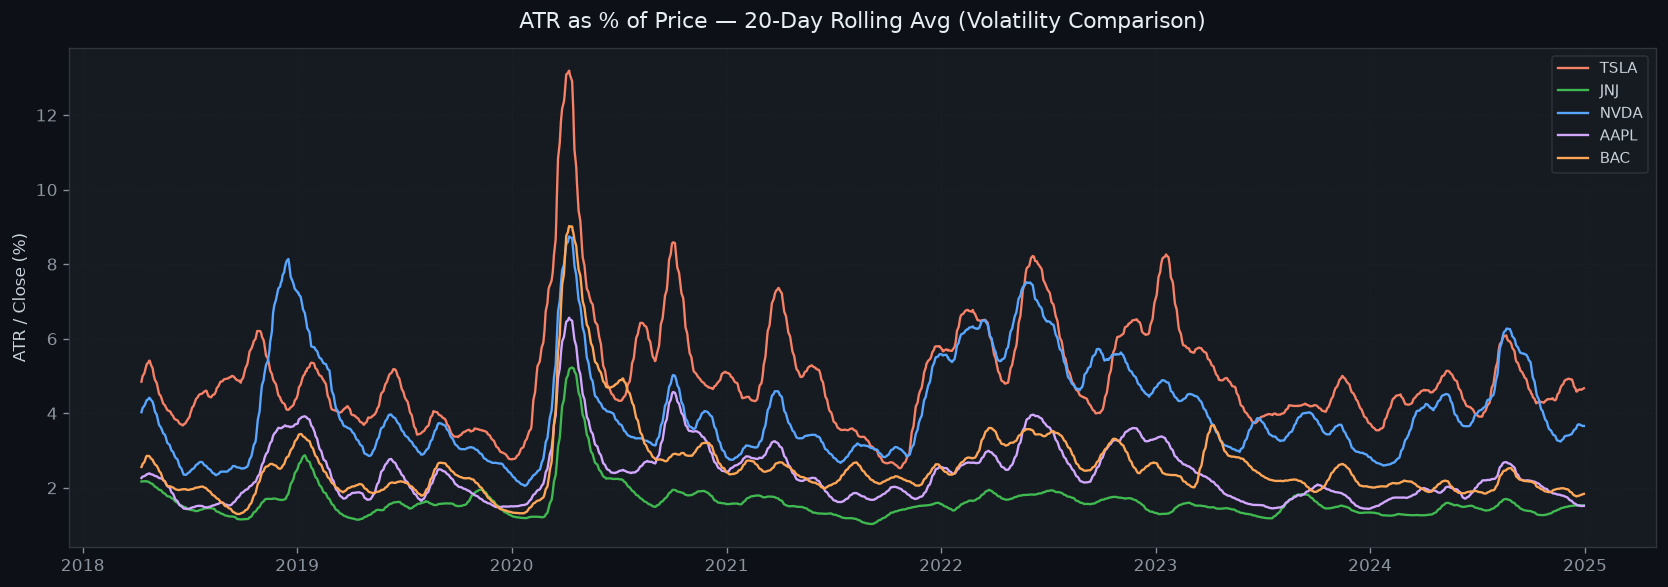

Saved → reports/day2_atr_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

palette = ['#f78166', '#3fb950', '#58a6ff', '#d2a8ff', '#ffa657']
compare_tickers = ['TSLA', 'JNJ', 'NVDA', 'AAPL', 'BAC']

for i, ticker in enumerate(compare_tickers):
    d = signals[ticker]
    atr_pct = (d['ATR'] / d['Close']) * 100
    ax.plot(d.index, atr_pct.rolling(20).mean(), color=palette[i], lw=1.4, label=ticker)

ax.set_title('ATR as % of Price — 20-Day Rolling Avg (Volatility Comparison)',
             fontsize=13, color='#e6edf3', pad=12)
ax.set_ylabel('ATR / Close (%)')
ax.legend(fontsize=9, facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig('../reports/day2_atr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day2_atr_comparison.png')

## 8. Save Signal CSVs

In [9]:
sig_dir = Path('../data/signals')
sig_dir.mkdir(exist_ok=True)

for ticker, df in signals.items():
    path = sig_dir / f'signals_{ticker}.csv'
    df.to_csv(path)

print(f'Signal CSVs saved to data/signals/ ({len(signals)} files)')
for f in sorted(sig_dir.glob('*.csv')):
    print(f'  {f.name:<35} {f.stat().st_size/1024:>7.1f} KB')

Signal CSVs saved to data/signals/ (10 files)
  signals_AAPL.csv                      547.0 KB
  signals_AMZN.csv                      538.2 KB
  signals_BAC.csv                       549.6 KB
  signals_GOOGL.csv                     545.0 KB
  signals_JNJ.csv                       550.2 KB
  signals_JPM.csv                       545.3 KB
  signals_MSFT.csv                      543.9 KB
  signals_NVDA.csv                      550.5 KB
  signals_TSLA.csv                      543.4 KB
  signals_XOM.csv                       544.1 KB


## ✅ Day 2 Complete

| Deliverable | Status |
|-------------|--------|
| EMA (20/50) for all tickers | ✅ |
| MACD (12,26,9) with histogram | ✅ |
| RSI (14) with zones | ✅ |
| Bollinger Bands (20, 2σ) | ✅ |
| ATR (14) + 6% trailing stop | ✅ |
| BUY / SELL / HOLD signals | ✅ |
| Signal CSVs in `data/signals/` | ✅ |
| 5 charts in `reports/` | ✅ |

**Next**: Day 3 — Backtesting Engine